In [1]:
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt

plt.style.use('default')

In [2]:
data = pd.read_csv('../data/behavioural/smp2_force_single_trial.tsv', sep='\t')
nogo = data.index[data['GoNogo']=='nogo']
bad = nogo.union(nogo + 1)
data_f = data.loc[~data.index.isin(bad)].reset_index(drop=True)
data_ff = data_f.loc[1:].copy()
data_ff['cuePrev'] = data_f.cue[:-1].to_numpy()
data_ff['UnexpectedPrev'] = data_f.Unexpected[:-1].to_numpy()

In [4]:
data_g = data_ff.groupby(['stimFinger', 'cue', 'sn', 'UnexpectedPrev']).mean(numeric_only=True).reset_index()

<Axes: xlabel='cue', ylabel='ring1'>

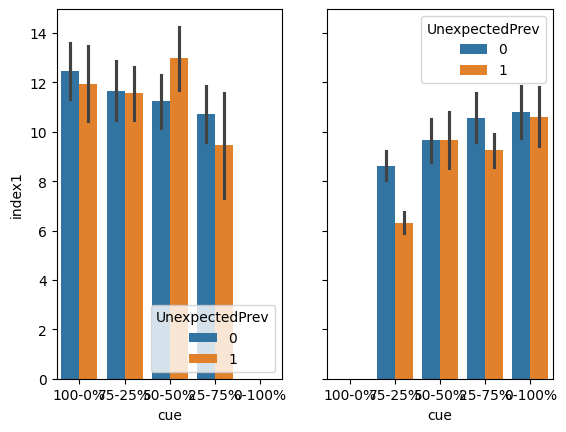

In [6]:
fig, axs = plt.subplots(1, 2, sharex=True, sharey=True)
stimIndex = data_g.stimFinger == 'index'
stimRing = data_g.stimFinger == 'ring'
sb.barplot(ax=axs[0], data=data_g[stimIndex], x='cue', y='index1', hue='UnexpectedPrev', order=['100-0%', '75-25%', '50-50%', '25-75%', '0-100%'], errorbar='se')
sb.barplot(ax=axs[1], data=data_g[stimRing], x='cue', y='ring1', hue='UnexpectedPrev', order=['100-0%', '75-25%', '50-50%', '25-75%', '0-100%'], errorbar='se')